<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/gen_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.3 MB/s eta 0:00:00


In [ ]:
#libaries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
pd.options.mode.copy_on_write = True
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/gender_classification_v7.csv")
print(df)

      long_hair  forehead_width_cm  forehead_height_cm  nose_wide  nose_long  \
0             1               11.8                 6.1          1          0   
1             0               14.0                 5.4          0          0   
2             0               11.8                 6.3          1          1   
3             0               14.4                 6.1          0          1   
4             1               13.5                 5.9          0          0   
...         ...                ...                 ...        ...        ...   
4996          1               13.6                 5.1          0          0   
4997          1               11.9                 5.4          0          0   
4998          1               12.9                 5.7          0          0   
4999          1               13.2                 6.2          0          0   
5000          1               15.4                 5.4          1          1   

      lips_thin  distance_nose_to_lip_l

# Data PreProcessing

* eda(explotaory data analysis)
* feature engineering
* model Building
* performance validation


In [ ]:
df.shape

(5001, 8)

In [ ]:
df.head(10)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
5,1,13.0,6.8,1,1,1,1,Male
6,1,15.3,6.2,1,1,1,0,Male
7,0,13.0,5.2,0,0,0,0,Female
8,1,11.9,5.4,1,0,1,1,Female
9,1,12.1,5.4,0,0,0,0,Female


In [ ]:
df.tail(10)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
4991,1,12.1,5.8,0,0,0,0,Female
4992,1,14.1,7.0,1,1,1,1,Male
4993,1,11.6,5.9,0,0,0,1,Female
4994,1,12.9,7.0,1,1,1,1,Male
4995,1,12.3,6.9,0,1,1,1,Male
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female
5000,1,15.4,5.4,1,1,1,1,Male


In [ ]:
#metadates of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


# data preprocessing
* handling null values
* handling duplicates
* checking for data type

In [ ]:
df.isnull().sum()

,0
long_hair,0
forehead_width_cm,0
forehead_height_cm,0
nose_wide,0
nose_long,0
lips_thin,0
distance_nose_to_lip_long,0
gender,0


In [ ]:
#methods for handling null value
#*inteputation methods
#*drop null values

In [ ]:
df.duplicated().sum()

np.int64(1768)

In [ ]:
# drop duplicates
df.drop_duplicates(inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
long_hair,int64
forehead_width_cm,float64
forehead_height_cm,float64
nose_wide,int64
nose_long,int64
lips_thin,int64
distance_nose_to_lip_long,int64
gender,object


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

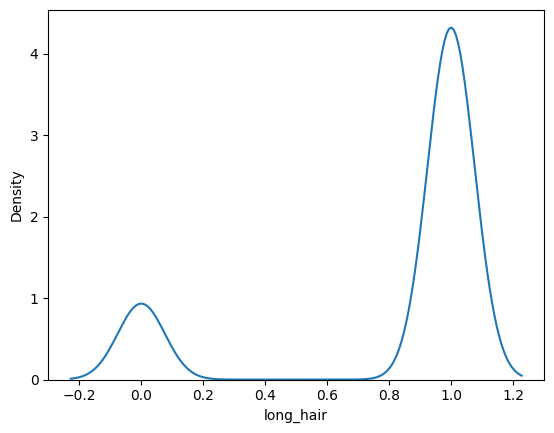

In [ ]:
sns.kdeplot(df['long_hair'])
plt.show()

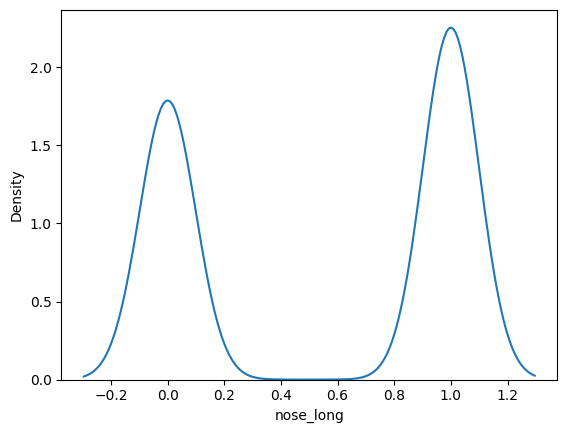

In [ ]:
sns.kdeplot(df['nose_long'])
plt.show()

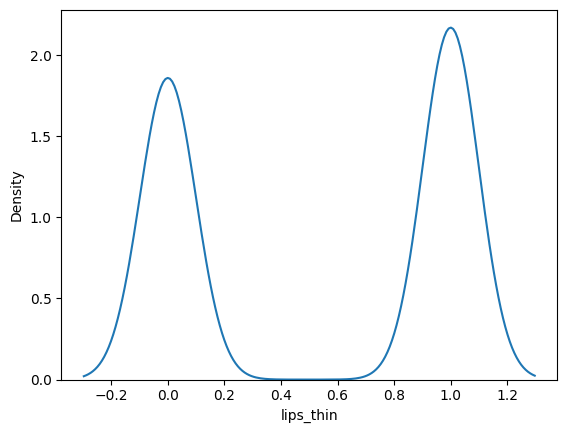

In [ ]:
sns.kdeplot(df['lips_thin'])
plt.show()

# univariate analysis

In [ ]:
df['gender'].nunique()

2

In [ ]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['gender'].value_counts()

,count
gender,
Male,1783
Female,1450


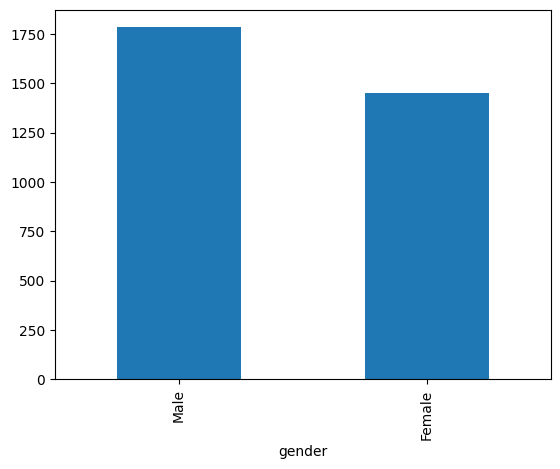

In [ ]:
df['gender'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
num= df.select_dtypes(include=np.number)
num.columns

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long'],
      dtype='object')

In [ ]:
cat = df.select_dtypes(include=object)
cat.columns

Index(['gender'], dtype='object')

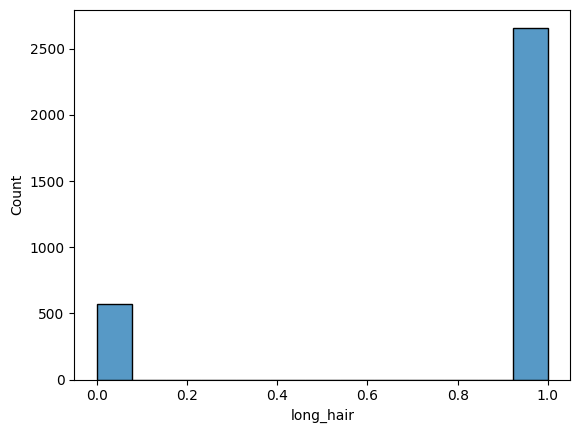

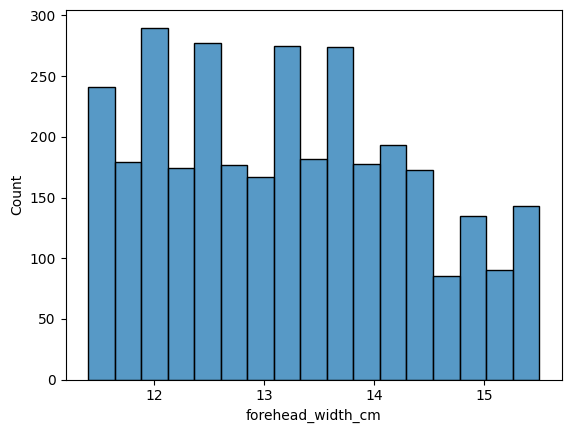

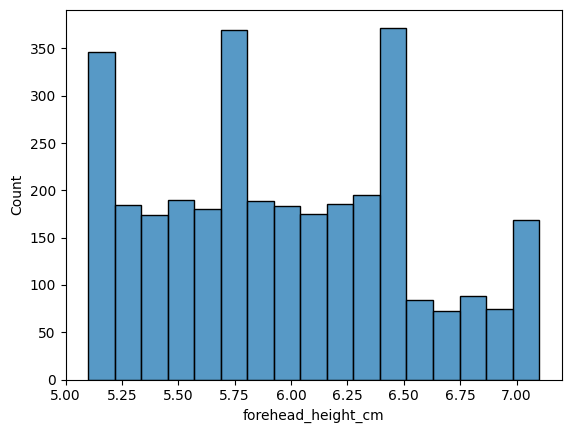

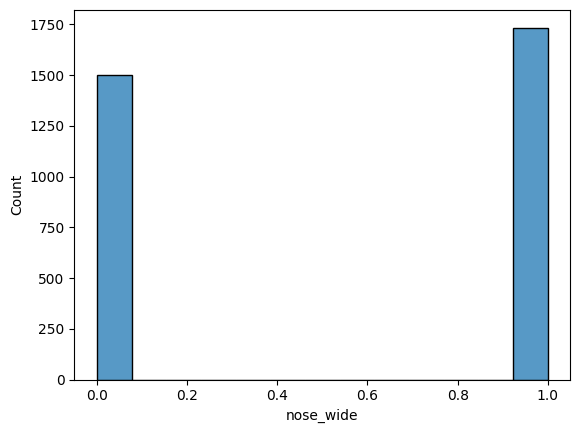

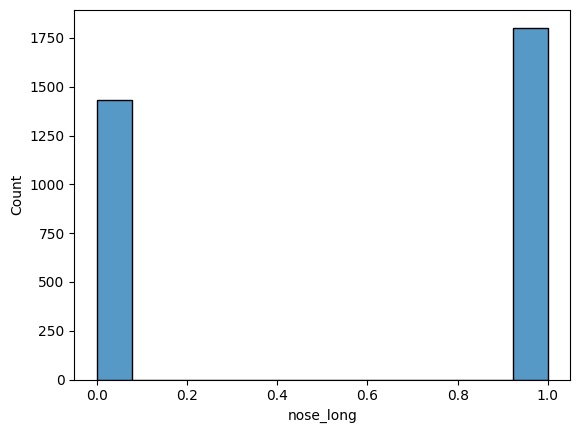

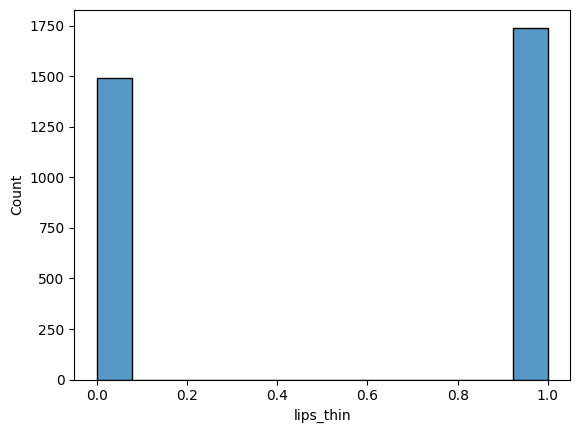

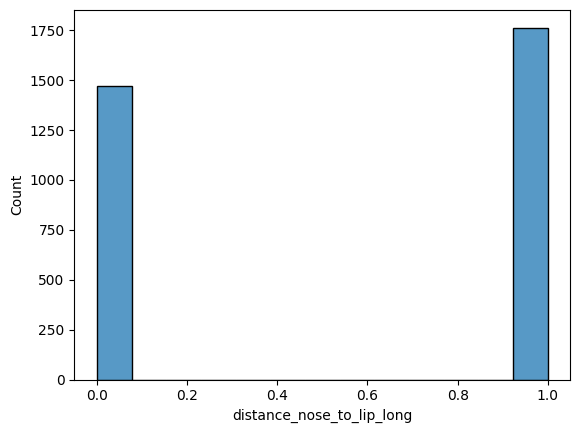

In [ ]:
# for numerical features
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

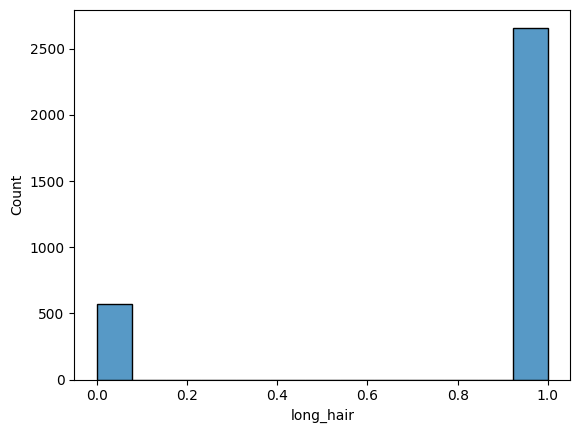

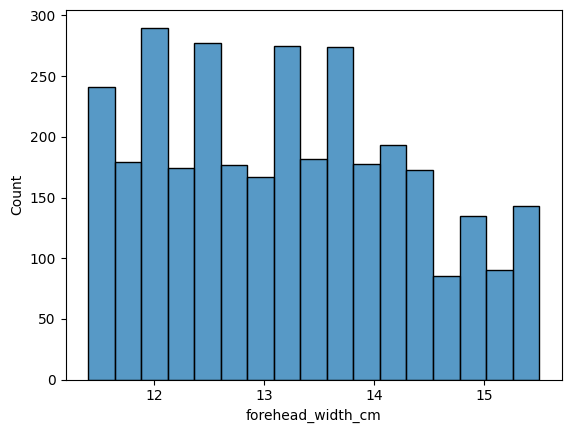

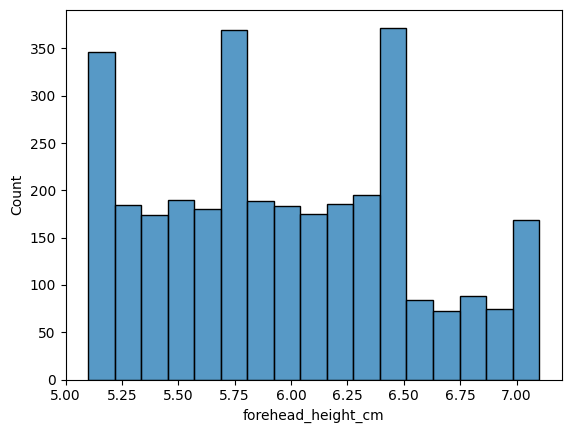

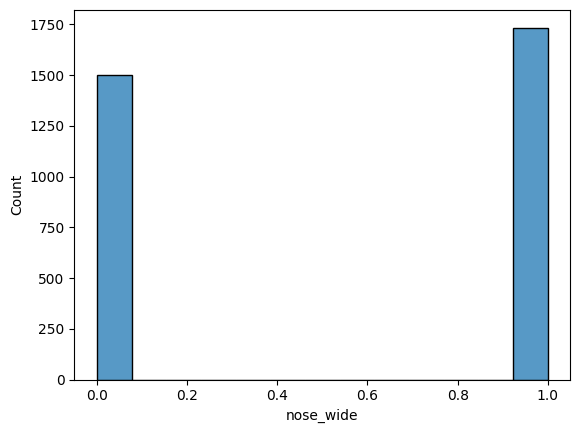

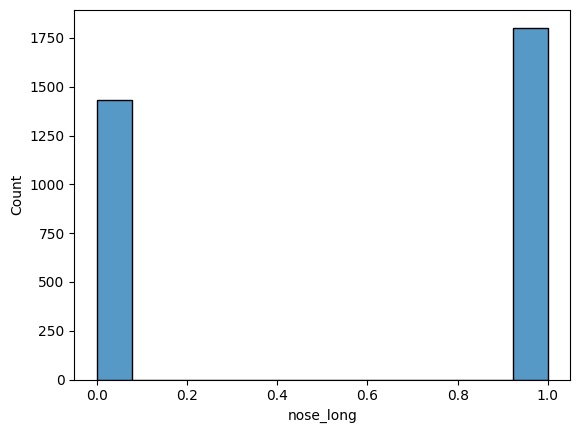

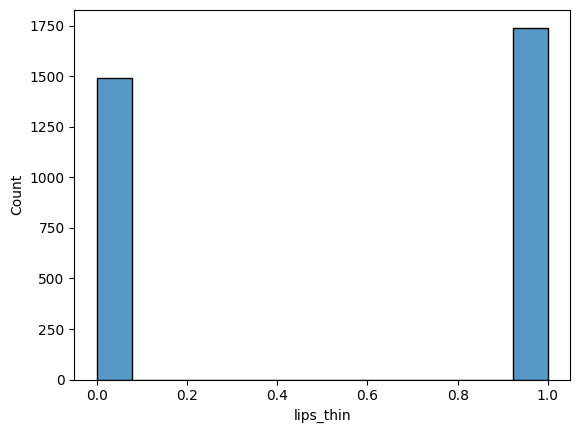

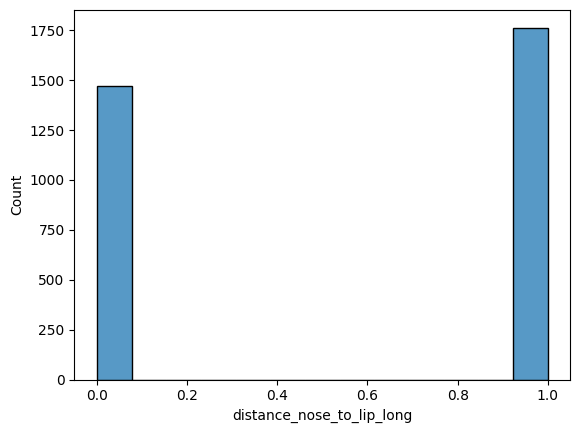

In [ ]:
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

#bivariate analysis


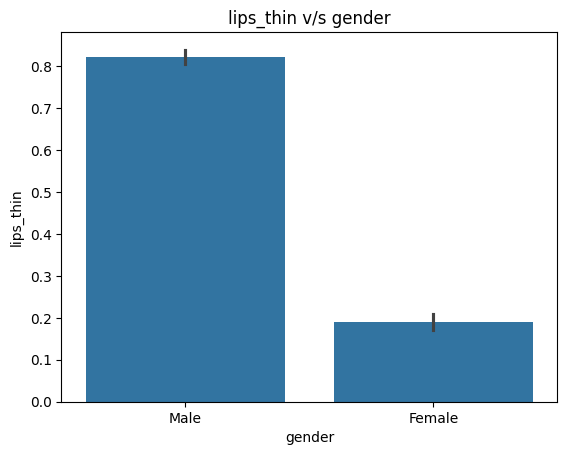

In [ ]:
#bivariate analysis for bmi and charges
sns.barplot(data=df,x='gender',y='lips_thin')
plt.title("lips_thin v/s gender")
plt.show()

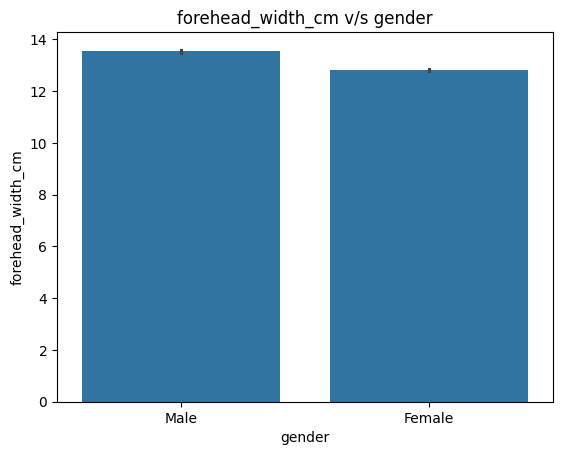

In [ ]:
sns.barplot(data=df,x='gender',y='forehead_width_cm')
plt.title("forehead_width_cm v/s gender")
plt.show()

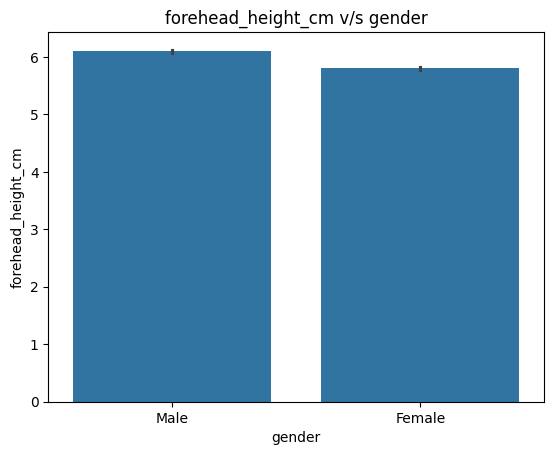

In [ ]:
sns.barplot(data=df,x='gender',y='forehead_height_cm')
plt.title("forehead_height_cm v/s gender")
plt.show()

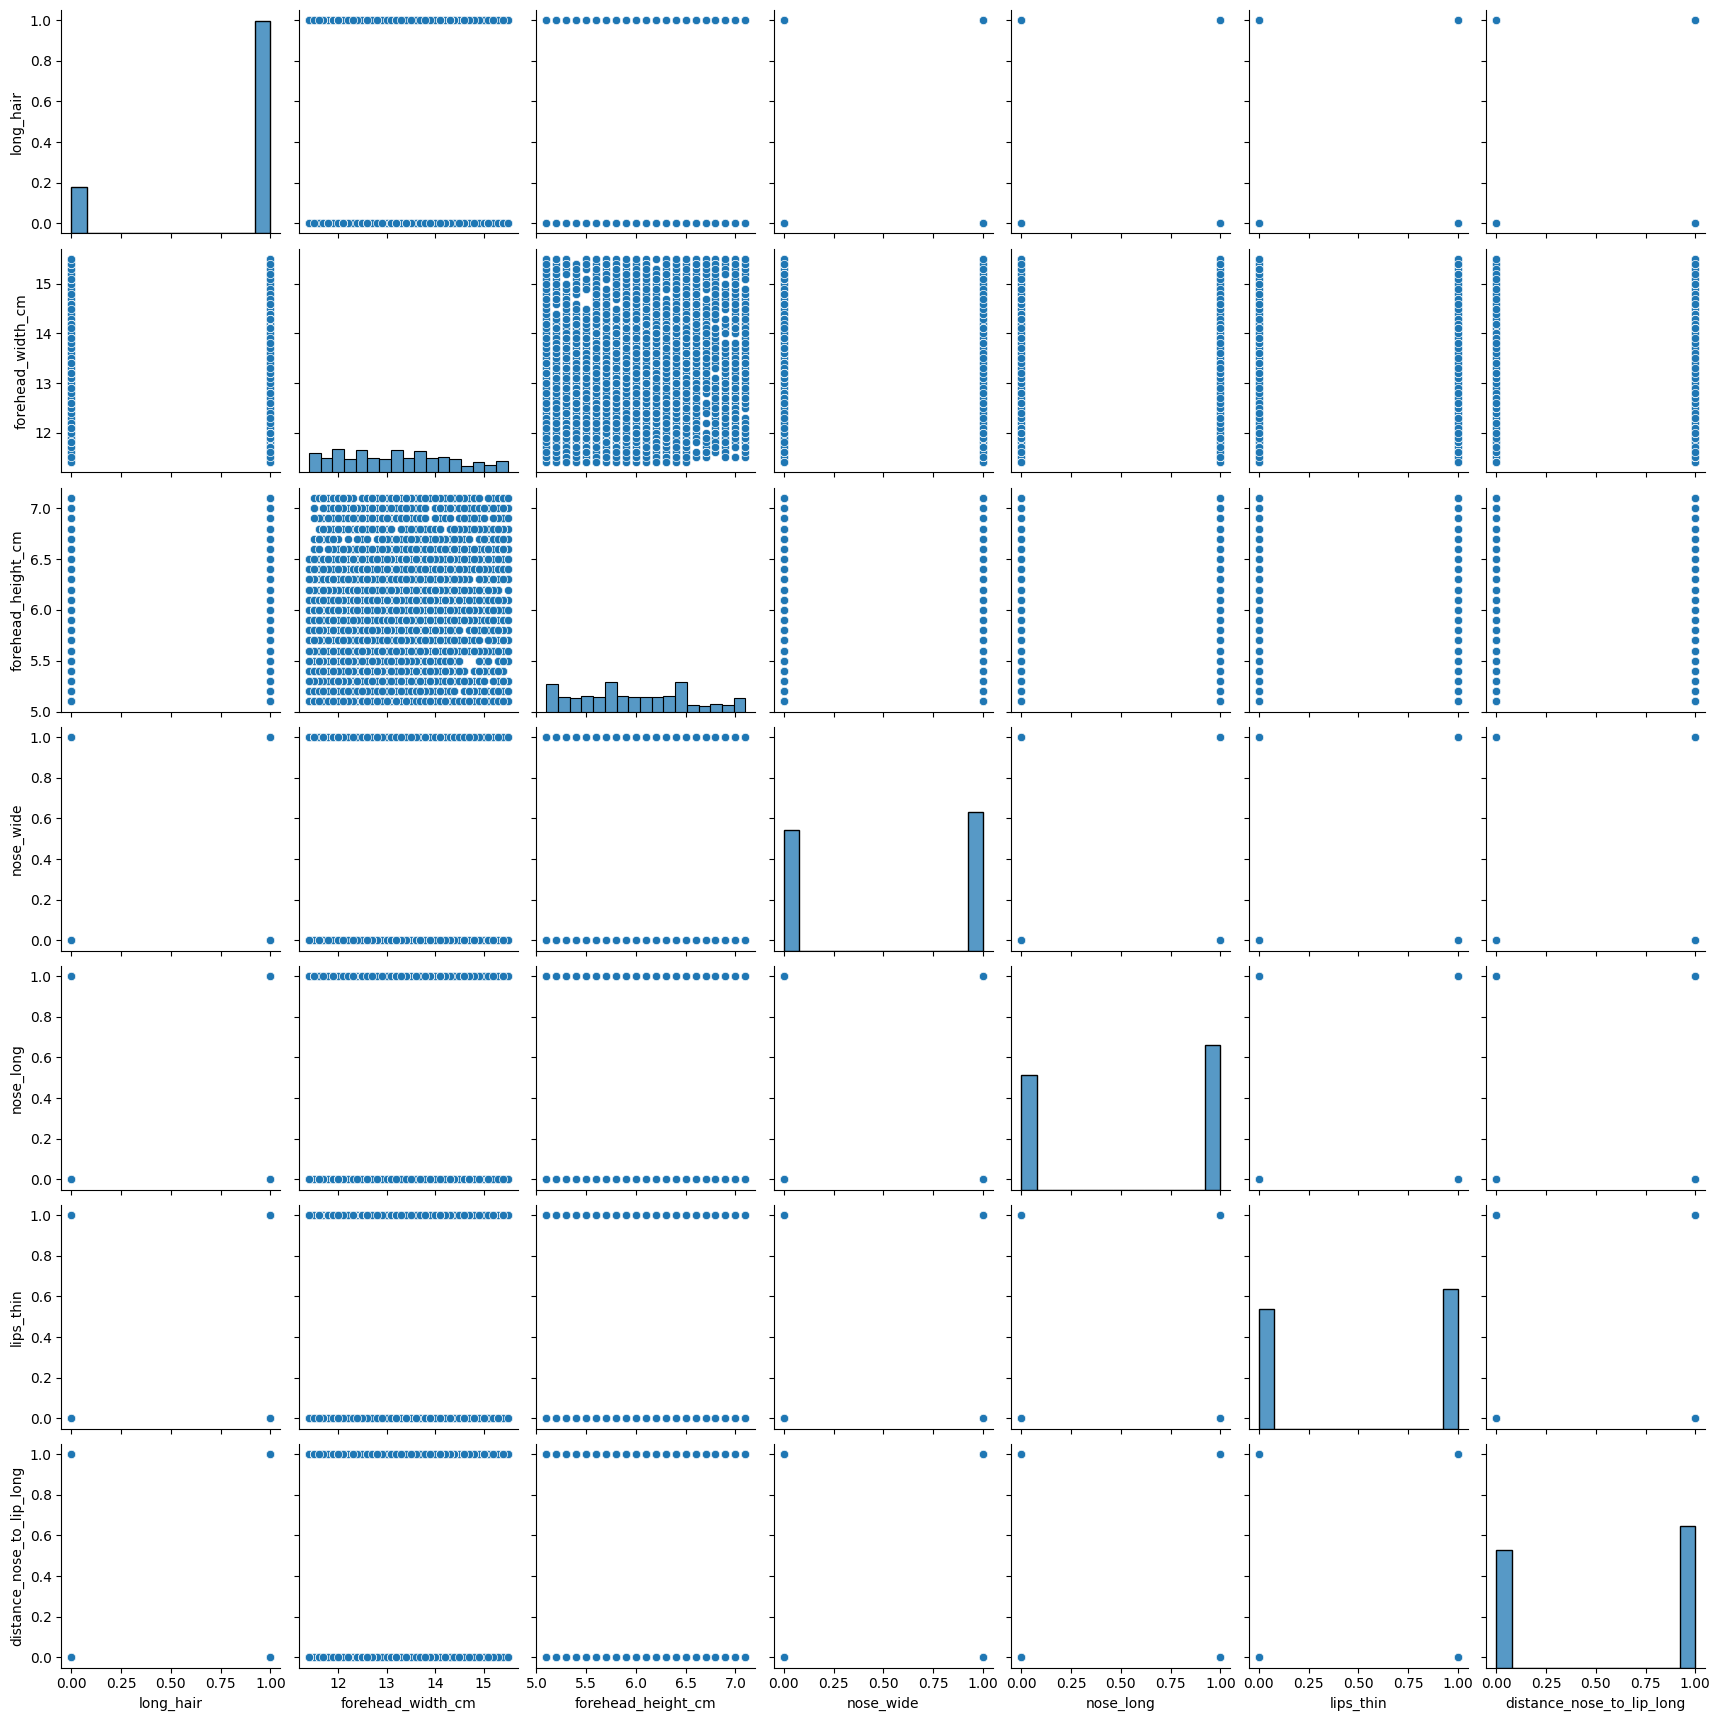

In [ ]:
sns.pairplot(df)
plt.show()

#multivariate analysis

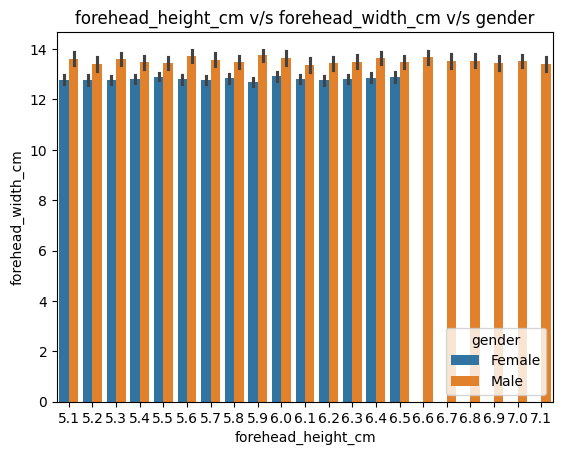

In [ ]:
sns.barplot(data=df,x='forehead_height_cm',y='forehead_width_cm',hue='gender')
plt.title("forehead_height_cm v/s forehead_width_cm v/s gender")
plt.show()

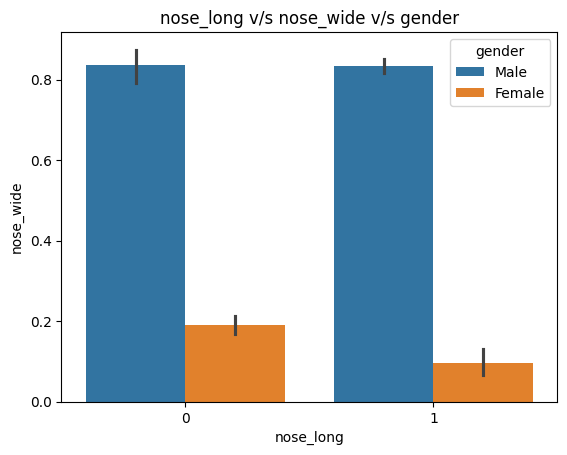

In [ ]:
sns.barplot(data=df,x='nose_long',y='nose_wide',hue='gender')
plt.title("nose_long v/s nose_wide v/s gender")
plt.show()

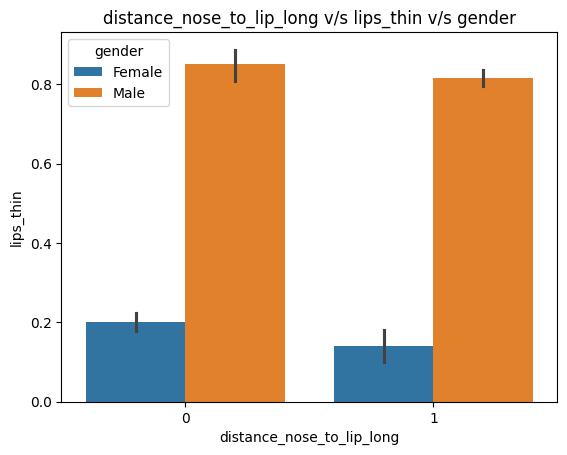

In [ ]:
sns.barplot(data=df,x='distance_nose_to_lip_long',y='lips_thin',hue='gender')
plt.title("distance_nose_to_lip_long v/s lips_thin v/s gender")
plt.show()

In [ ]:
#multivarient for numerical hue as make
num=df.select_dtypes(include=np.number)
num.columns

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long'],
      dtype='object')

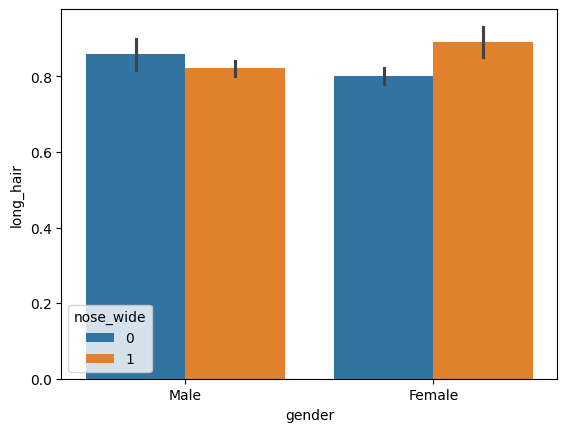

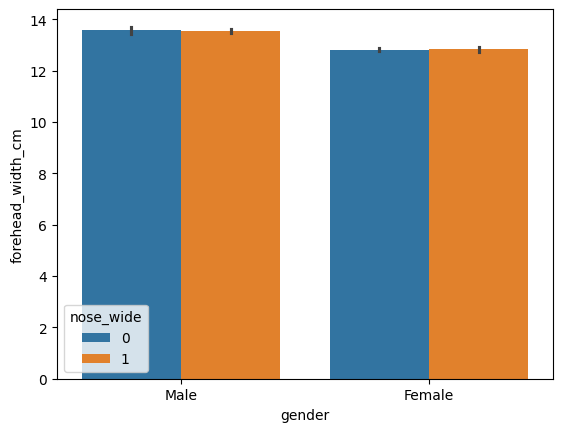

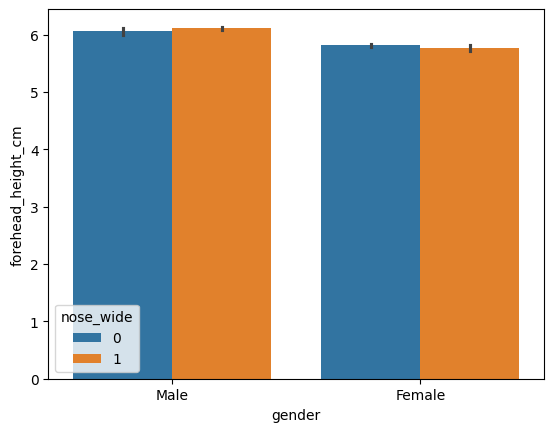

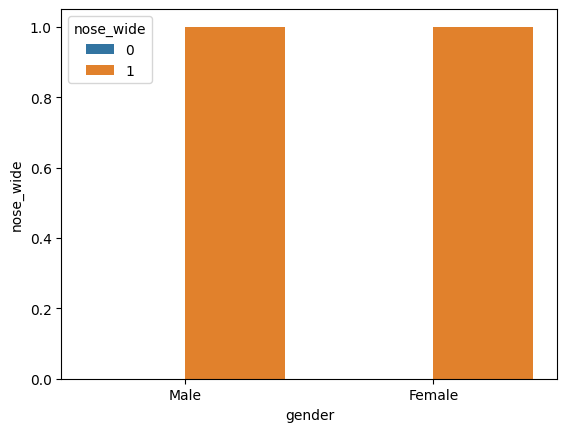

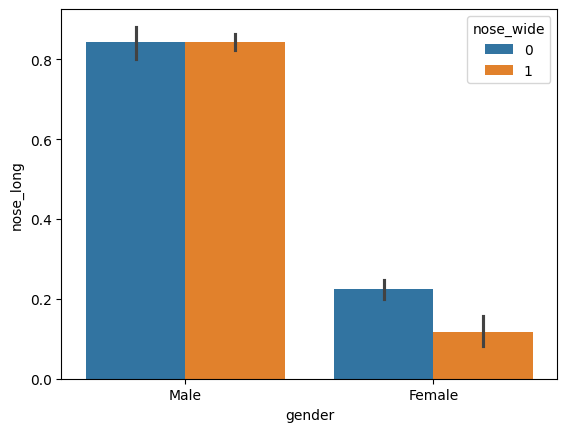

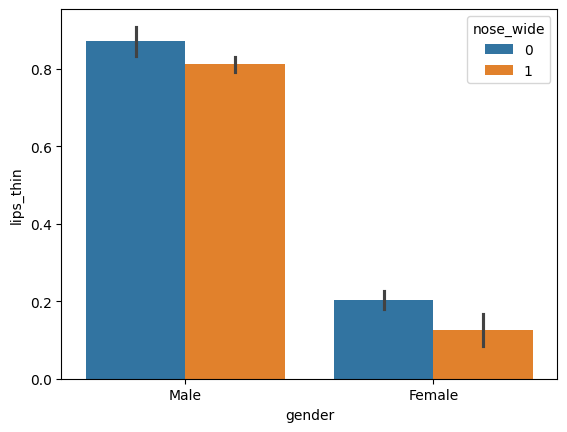

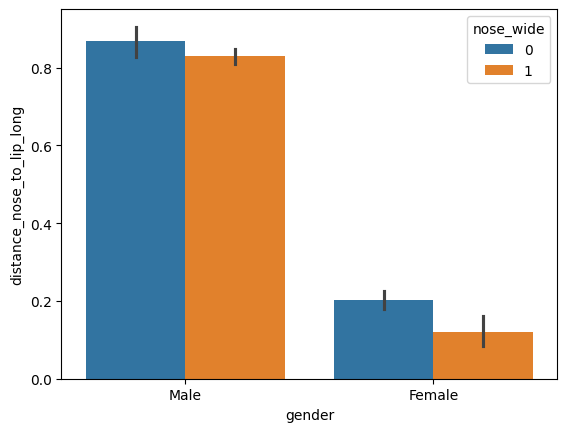

In [ ]:
num=df.select_dtypes(include=['number']).columns.tolist()
for i in num:
  sns.barplot(x=df['gender'],y=df[i],hue=df['nose_wide'])
  plt.show()

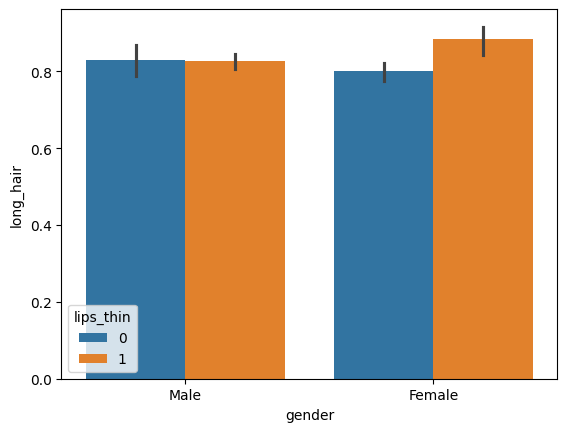

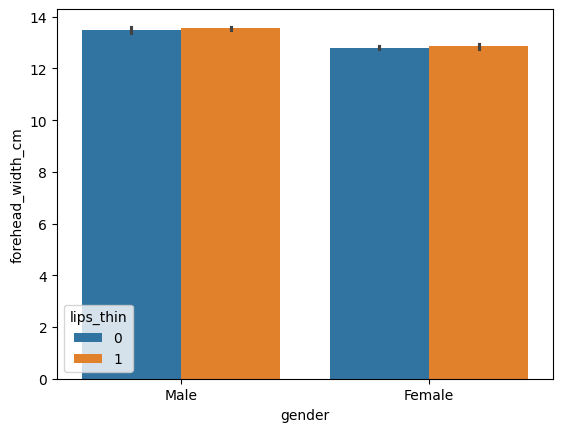

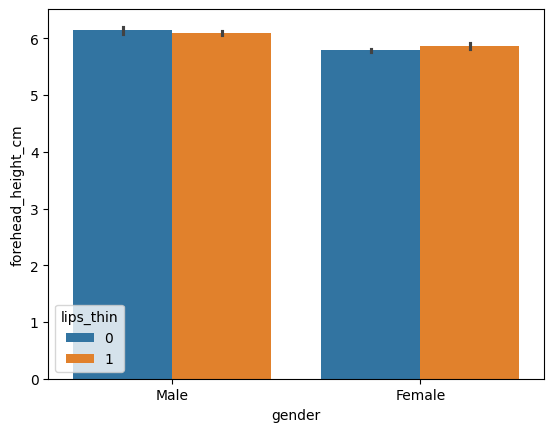

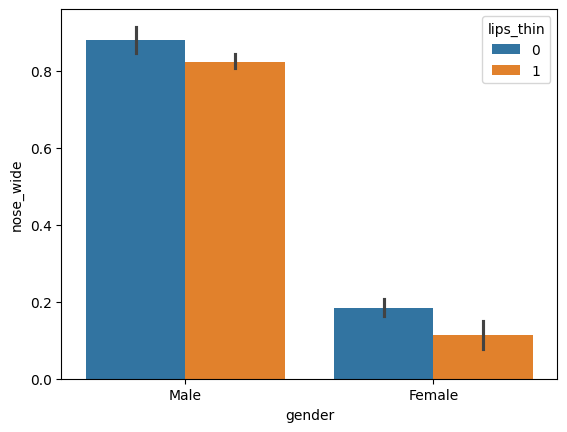

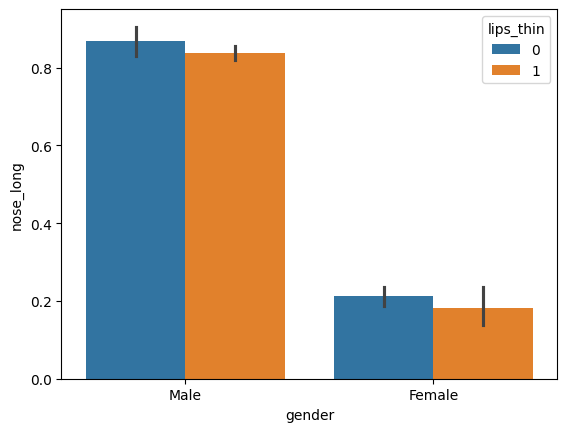

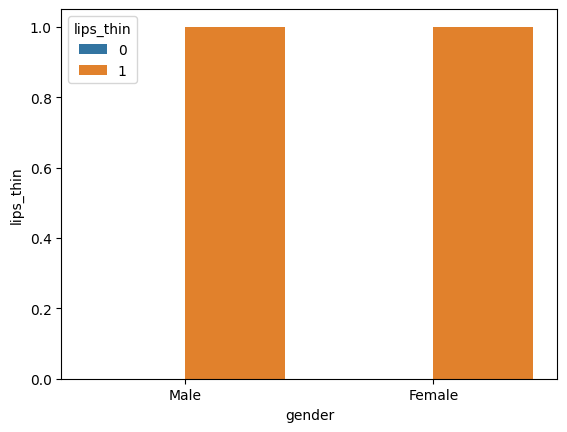

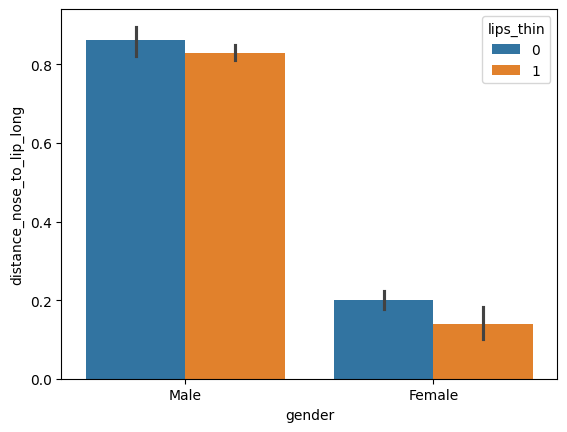

In [ ]:
num=df.select_dtypes(include=['number']).columns.tolist()
for i in num:
  sns.barplot(x=df['gender'],y=df[i],hue=df['lips_thin'])
  plt.show()

#Feature Engineering

#Data Encoding
* label encoding
* one hot encoding
*target encoding

#label encoding

In [ ]:
Ib_gender = LabelEncoder()
df['gender'] = Ib_gender.fit_transform(df['gender'])

In [ ]:
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0
...,...,...,...,...,...,...,...,...
4986,1,11.7,6.1,1,1,0,1,1
4990,1,12.6,5.7,0,0,1,0,0
4992,1,14.1,7.0,1,1,1,1,1
4993,1,11.6,5.9,0,0,0,1,0


# Handling outlayers

In [ ]:
q1 =np.quantile(df['forehead_height_cm'],0.25)
q3 =np.quantile(df['forehead_height_cm'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True,inplace=True)
for i in range(len(df)):
   if df.loc[i, 'forehead_height_cm'] > max_bound:
        df.loc[i, 'forehead_height_cm'] = max_bound

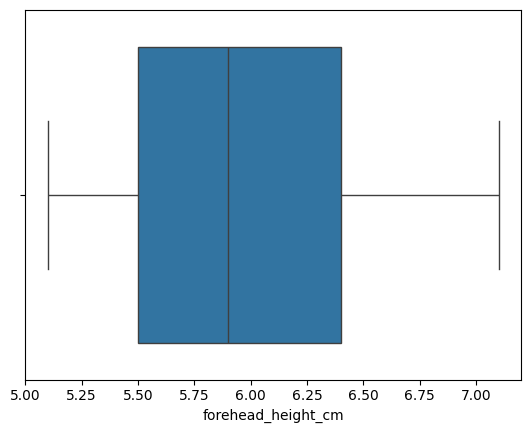

In [ ]:
sns.boxplot(df['forehead_height_cm'],orient='h')
plt.show()

In [ ]:
q1 =np.quantile(df['forehead_width_cm'],0.25)
q3 =np.quantile(df['forehead_width_cm'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True,inplace=True)
for i in range(len(df)):
   if df.loc[i, 'forehead_width_cm'] > max_bound:
        df.loc[i, 'forehead_width_cm'] = max_bound

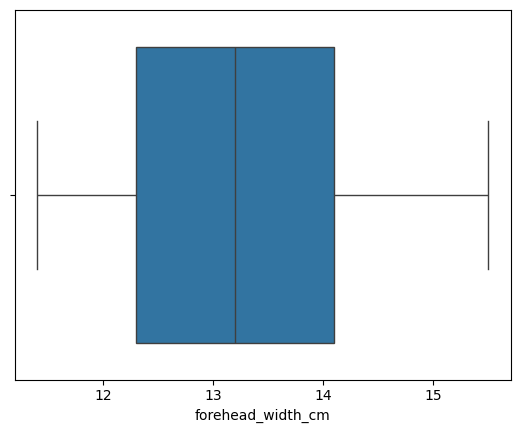

In [ ]:
sns.boxplot(df['forehead_width_cm'],orient='h')
plt.show()

# checking for corelation

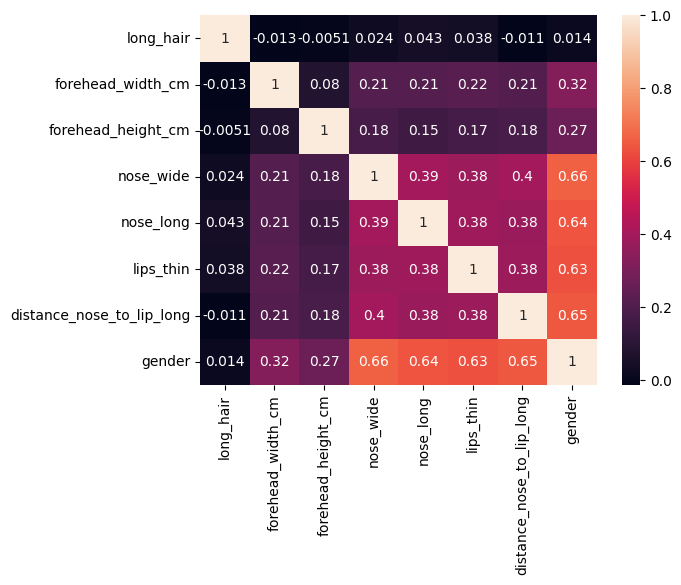

In [ ]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
#picking coloumns from highest corelation
df_new = df[['gender','distance_nose_to_lip_long','nose_wide','nose_long','lips_thin']]

In [ ]:
df_new

,gender,distance_nose_to_lip_long,nose_wide,nose_long,lips_thin
0,1,1,1,0,1
1,0,0,0,0,1
2,1,1,1,1,1
3,1,1,0,1,1
4,0,0,0,0,0
...,...,...,...,...,...
3228,1,1,1,1,0
3229,0,0,0,0,1
3230,1,1,1,1,1
3231,0,1,0,0,0


# Data scaling

# model building

In [ ]:
x=df_new.drop('gender',axis=1)
y=df_new['gender']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train

,distance_nose_to_lip_long,nose_wide,nose_long,lips_thin
361,0,1,1,1
135,0,1,1,0
1831,1,1,0,1
2341,0,1,0,1
1206,0,0,0,0
...,...,...,...,...
1095,1,1,1,1
1130,0,0,0,0
1294,1,0,0,0
860,0,0,0,0


In [ ]:
y_train

,gender
361,1
135,0
1831,1
2341,1
1206,0
...,...
1095,1
1130,0
1294,0
860,0


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2586, 4)
(647, 4)
(2586,)
(647,)


# knn

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
knn.score(x_train,y_train)

0.9307811291569992

In [ ]:
knn.score(x_test,y_test)

0.9474497681607419

In [ ]:
y_pred=knn.predict(x_test)
y_pred

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,

In [ ]:
result=pd.DataFrame({'actual':y_test,'predicted':y_pred})
result

,actual,predicted
1022,1,1
1398,0,0
1234,0,0
30,1,1
139,1,1
...,...,...
691,0,0
2608,0,0
805,0,0
1133,1,0


In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.7893154043596522
Mean Squared Error: 0.05255023183925812


# logistic regression

In [ ]:
log=LogisticRegression()
log.fit(x_train,y_train)

LogisticRegression()

In [ ]:
log.score(x_train,y_train)

0.9423820572312451

In [ ]:
log.score(x_test,y_test)

0.9381761978361669

In [ ]:
#evaluation
y_pred_log = log.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log,labels=[0,1]))

Accuracy: 0.9381761978361669
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       308
           1       0.93      0.95      0.94       339

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



In [ ]:
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Confusion Matrix:
 [[285  23]
 [ 17 322]]


# decision tree

In [ ]:
# Create Decision Tree classifer object using entropy
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

In [ ]:
clf = clf.fit(x_train,y_train)

In [ ]:
y_pred_df = clf.predict(x_test)

In [ ]:
clf.score(x_train,y_train)

0.9412219644238206

In [ ]:
clf.score(x_test,y_test)

0.9397217928902627

In [ ]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9474497681607419


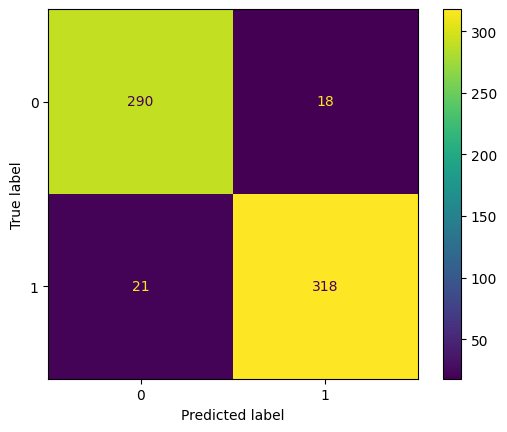

In [ ]:
cm = confusion_matrix(y_test, y_pred_df)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# random forest

In [ ]:
iris = load_iris()
x = iris.data
y = iris.target

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9381761978361669

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       308
           1       0.93      0.95      0.94       339

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



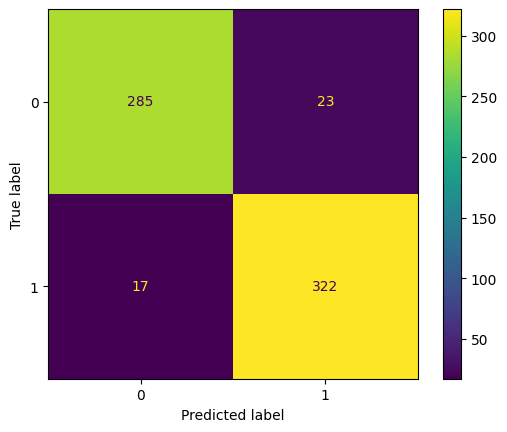

In [ ]:
rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=rf)
disp.plot()

# adaboost

In [ ]:
ab=AdaBoostClassifier(n_estimators=10, random_state=42)
ab.fit(x_train, y_train)

AdaBoostClassifier(n_estimators=10, random_state=42)

In [ ]:
y_pred_ab = ab.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ab))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ab))

Accuracy: 0.9443585780525502

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94       308
           1       0.91      0.99      0.95       339

    accuracy                           0.94       647
   macro avg       0.95      0.94      0.94       647
weighted avg       0.95      0.94      0.94       647



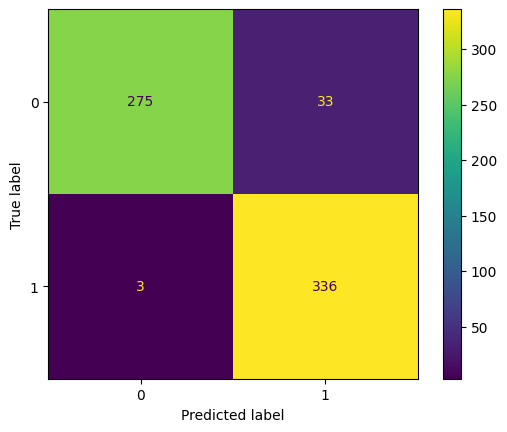

In [ ]:
ab = confusion_matrix(y_test, y_pred_ab)
disp = ConfusionMatrixDisplay(confusion_matrix=ab)
disp.plot()

# support vector classification

In [ ]:
sv = SVC()
sv.fit(x_train, y_train)

SVC()

In [ ]:
y_pred_sv = sv.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_sv))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sv))

Accuracy: 0.9381761978361669

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       308
           1       0.93      0.95      0.94       339

    accuracy                           0.94       647
   macro avg       0.94      0.94      0.94       647
weighted avg       0.94      0.94      0.94       647



# naive bayes classification

In [ ]:
nb = GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.9319938176197836

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93       308
           1       0.99      0.88      0.93       339

    accuracy                           0.93       647
   macro avg       0.94      0.93      0.93       647
weighted avg       0.94      0.93      0.93       647



#model comparison graph

In [ ]:
# Initialize models
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [ ]:
# Train, predict and collect accuracy
accuracy_scores = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)

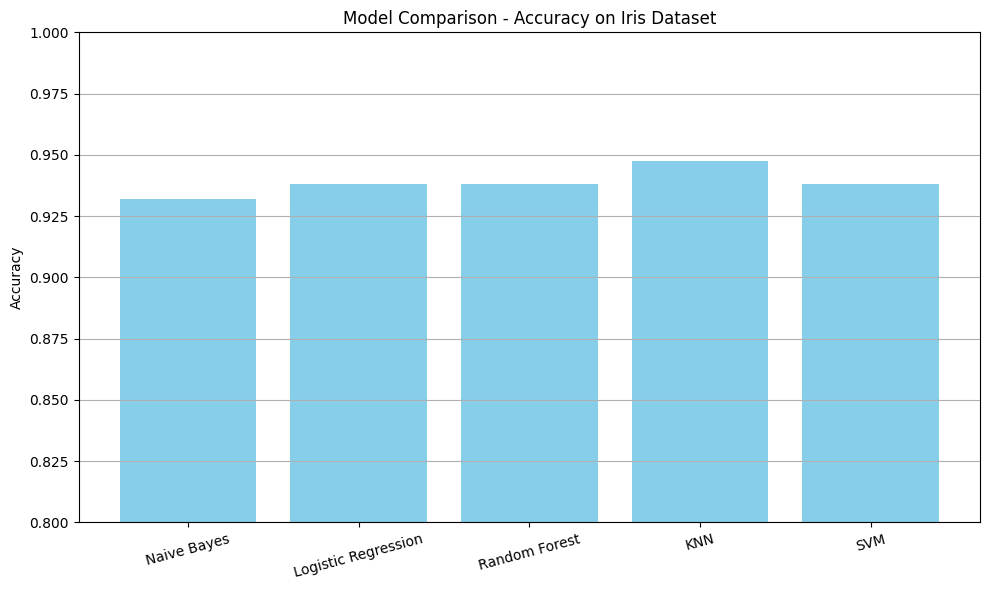

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color='skyblue')
plt.title('Model Comparison - Accuracy on Iris Dataset')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.grid(axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Initialize models
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}
# Score storage
results = []

In [ ]:
# Loop through models
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

In [ ]:
# Create DataFrame
df_results = pd.DataFrame(results)
print(df_results)

                 Model  Accuracy  Precision    Recall  F1 Score
0          Naive Bayes  0.931994   0.935768  0.934658  0.931986
1  Logistic Regression  0.938176   0.938521  0.937589  0.937973
2        Random Forest  0.938176   0.938521  0.937589  0.937973
3                  KNN  0.947450   0.947135  0.947923  0.947383
4                  SVM  0.938176   0.938521  0.937589  0.937973
